### Phase 2: Feature Selection with simple methods

In [1]:
import pandas as pd
from data_preprocessing import create_train_test_val_sets, get_processed_df
import joblib
import os
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
#Create test train splits
x_mendeley, y_mendeley = get_processed_df(r"../data/raw/Mendeley Dataset.csv")
x_kaggle, y_kaggle= get_processed_df(r"../data/raw/dataset_phishing.csv")

mendeley_sets = create_train_test_val_sets(x_mendeley,y_mendeley, label_col="Label", test_size=0.2, n_splits=5)
kaggle_sets = create_train_test_val_sets(x_kaggle,y_kaggle, label_col="Label", test_size=0.2, n_splits=5)

----------Processing None Dataset----------

Class Distribution:
Label
0    0.518415
1    0.481585
Name: proportion, dtype: float64
int64

Total Missing Values: 0
No categorical features to hash
Shape After Processing: (247950, 42)
True
----------Processing None Dataset----------

Class Distribution:
Label
legitimate    0.5
phishing      0.5
Name: proportion, dtype: float64
object

Total Missing Values: 0
Shape After Processing: (11430, 32856)
True
Train/validation/test split prepared: 210757 instances for training, 37193 instances for validation, 49590 instances for testing
Stratified 5-fold CV splits created.
Train/validation/test split prepared: 9715 instances for training, 1715 instances for validation, 2286 instances for testing
Stratified 5-fold CV splits created.


In [3]:
kaggle_sets["y_train"] = kaggle_sets["y_train"].astype(int)
kaggle_sets["y_val"] = kaggle_sets["y_val"].astype(int)
kaggle_sets["y_test"] = kaggle_sets["y_test"].astype(int)

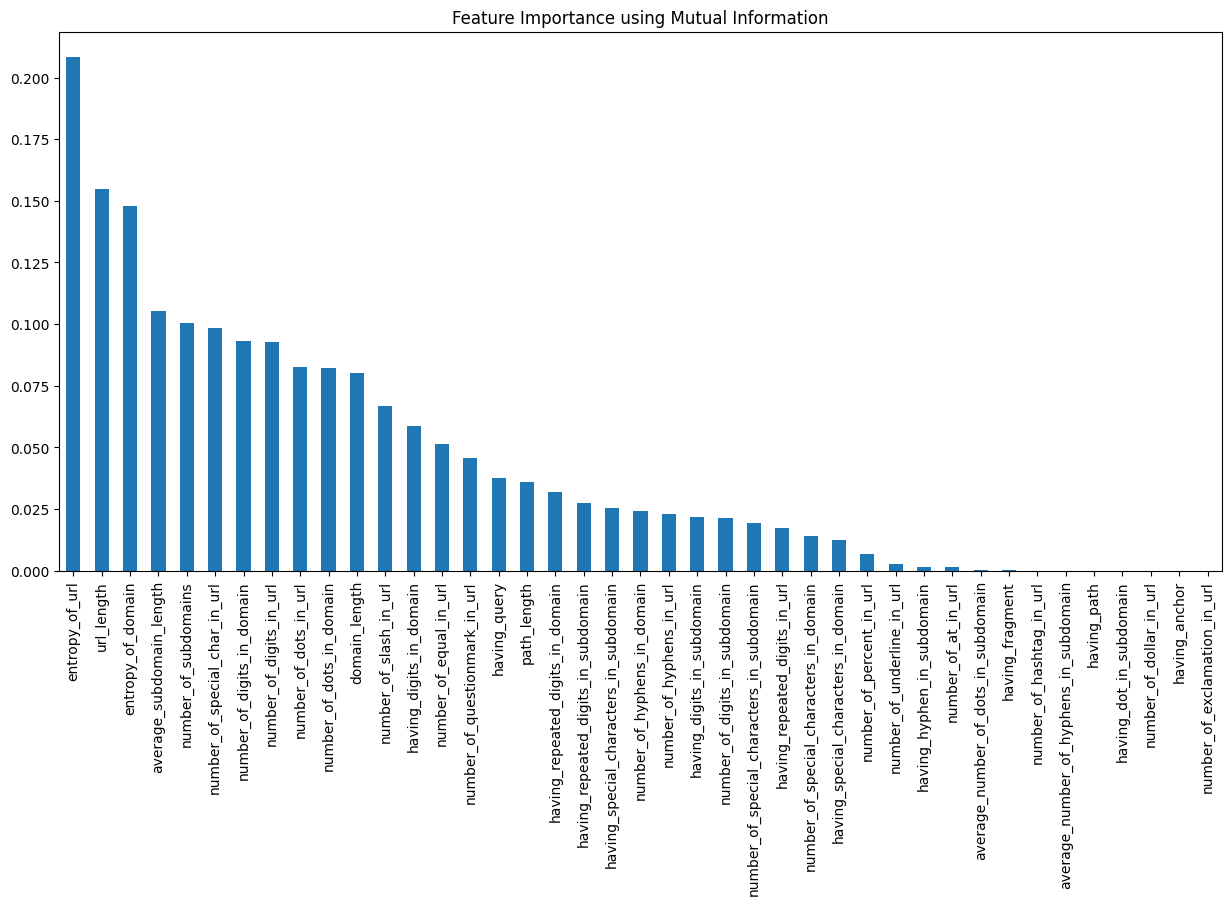

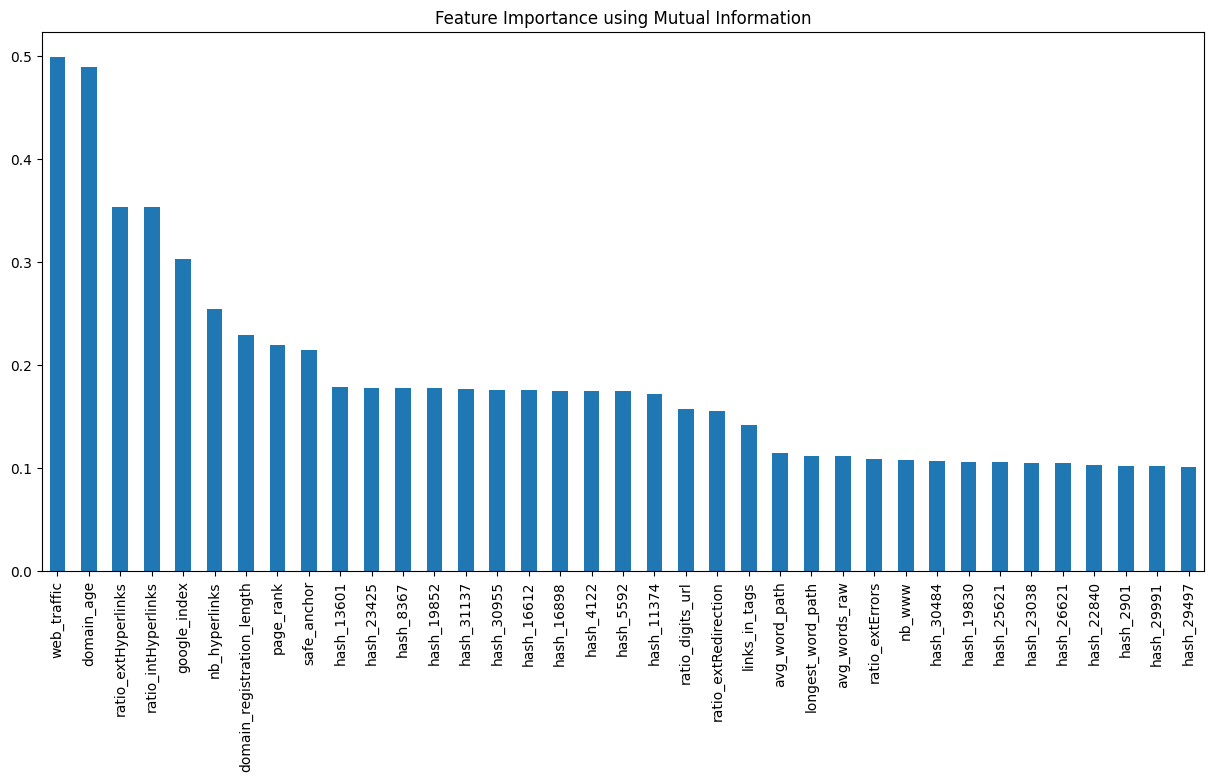

In [4]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

#Mendeley
features = mendeley_sets["x_train"].columns
mi_mendeley = mutual_info_classif(mendeley_sets["x_train"], mendeley_sets["y_train"], random_state=42)
mi_df_mendeley = pd.Series(mi_mendeley, index=features)

#plot to see the best features
mi_df_mendeley.sort_values(ascending=False).plot.bar(figsize=(15, 7))
plt.title("Feature Importance using Mutual Information")
plt.show()


#Phiusiil
features = kaggle_sets["x_train"].columns
mi_phiusiil = mutual_info_classif(kaggle_sets["x_train"], kaggle_sets["y_train"], random_state=42)
mi_df_phusiil = pd.Series(mi_phiusiil, index=features)

#plot to see the best features
mi_df_phusiil[mi_df_phusiil > 0.1].sort_values(ascending=False).plot.bar(figsize=(15, 7))
plt.title("Feature Importance using Mutual Information")
plt.show()

In [5]:
#import phase 1 models
xgb_mendeley = joblib.load('./models/phase_1/xgboost_mendeley_no_fs.joblib')
xgb_kaggle = joblib.load('./models/phase_1/xgboost_kaggle_no_fs.joblib')
logreg_mendeley = joblib.load('./models/phase_1/logreg_mendeley_no_fs.joblib')
logreg_kaggle = joblib.load('./models/phase_1/logreg_kaggle_no_fs.joblib')
rf_mendeley = joblib.load('./models/phase_1/rf_mendeley_no_fs.joblib')
rf_kaggle = joblib.load('./models/phase_1/rf_kaggle_no_fs.joblib')

In [6]:
#train models on reduced feature set
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.feature_selection import SelectKBest, VarianceThreshold, chi2, f_classif, mutual_info_classif
from sklearn.base import clone
from scipy.sparse import hstack, csr_matrix

def get_k_values(dataset, model, values, dataset_name, model_name, selector_func, param_name, method=''):
    performance_history = []
    best_values = {"f1": 0, param_name: 0}

    X_train = dataset["x_train"]
    X_val = dataset["x_val"]

    numeric_cols = [col for col in X_train.columns if not col.startswith("hash")]
    hash_cols = [col for col in X_train.columns if col.startswith("hash")]

    for val in values:
        model_clone = clone(model)
        selector = selector_func(val)

        #choose which cols to transform
        if method == "chi2":
            X_train_transform = X_train[hash_cols]
            X_val_transform = X_val[hash_cols]
            X_train_keep = X_train[numeric_cols]
            X_val_keep = X_val[numeric_cols]
        elif method == "anova":
            X_train_transform = X_train[numeric_cols]
            X_val_transform = X_val[numeric_cols]
            X_train_keep = X_train[hash_cols]
            X_val_keep = X_val[hash_cols]
        else:
            X_train_transform = X_train
            X_val_transform = X_val
            X_train_keep = None
            X_val_keep = None
            
        selector.fit(X_train_transform, dataset["y_train"])

        X_train_selected = selector.transform(X_train_transform)
        X_val_selected = selector.transform(X_val_transform)

        if X_train_keep is not None and X_val_keep is not None:
            X_train_selected = hstack([X_train_keep, X_train_selected])
            X_val_selected = hstack([X_val_keep, X_val_selected])

        #only get the names for the selected features from transformed set (relevant for chi2 and anova)
        try:
            selected_names = list(X_train_transform.columns[selector.get_support()])
        except:
            selected_names = None

        #train model on all data to get the full picture
        model_clone.fit(X_train_selected, dataset["y_train"])
        y_val_pred = model_clone.predict(X_val_selected)

        score = f1_score(dataset["y_val"], y_val_pred)
        print("Model =", model_name, param_name, "=", val, " f1_score =", score)
        
        if score > best_values["f1"]:
            best_values = {"f1": score, param_name: val}

        performance_history.append({
            'Dataset': dataset_name,
            'Model': model_name,
            param_name: val,
            'f1_Score': score,
            'Precision': precision_score(dataset["y_val"], y_val_pred),
            'Recall': recall_score(dataset["y_val"], y_val_pred),
            'Features': selected_names
        })
    return performance_history, best_values

mi_performance_history = []
chi2_performance_history = []
anova_performance_history = []
vt_performance_history = []

#perform feature selection on mendeley dataset
k_values = [10, 15, 20, 25, 30, 35, 40]
threshold_values = [0.01, 0.05, 0.1, 0.2, 0.5]
print("=== Mendeley Results ===")
#chi2
performance, best_mendeley_xgb_chi2 = get_k_values(mendeley_sets, xgb_mendeley, k_values, "Mendeley", 'XGBoost', lambda v: SelectKBest(chi2, k=v), "k")
chi2_performance_history += performance
performance, best_mendeley_logreg_chi2 = get_k_values(mendeley_sets, logreg_mendeley, k_values, "Mendeley", 'LogReg', lambda v: SelectKBest(chi2, k=v), "k")
chi2_performance_history += performance
performance, best_mendeley_rf_chi2 = get_k_values(mendeley_sets, rf_mendeley, k_values, "Mendeley", 'RF', lambda v: SelectKBest(chi2, k=v), "k")
chi2_performance_history += performance

#anova
performance, best_mendeley_xgb_anova = get_k_values(mendeley_sets, xgb_mendeley, k_values, "Mendeley", 'XGBoost', lambda v: SelectKBest(f_classif, k=v), "k")
anova_performance_history += performance
performance, best_mendeley_logreg_anova = get_k_values(mendeley_sets, logreg_mendeley, k_values, "Mendeley", 'LogReg', lambda v: SelectKBest(f_classif, k=v), "k")
anova_performance_history += performance
performance, best_mendeley_rf_anova = get_k_values(mendeley_sets, rf_mendeley, k_values, "Mendeley", 'RF', lambda v: SelectKBest(f_classif, k=v), "k")
anova_performance_history += performance

#mutual information
performance, best_mendeley_xgb_mi = get_k_values(mendeley_sets, xgb_mendeley, k_values, "Mendeley", 'XGBoost', lambda v: SelectKBest(mutual_info_classif, k=v), "k")
mi_performance_history += performance    
performance, best_mendeley_logreg_mi = get_k_values(mendeley_sets, logreg_mendeley, k_values, "Mendeley", 'LogReg', lambda v: SelectKBest(mutual_info_classif, k=v), "k")
mi_performance_history += performance   
performance, best_mendeley_rf_mi = get_k_values(mendeley_sets, rf_mendeley, k_values, "Mendeley", 'RF', lambda v: SelectKBest(mutual_info_classif, k=v), "k")
mi_performance_history += performance   

#variance threshold
performance, best_mendeley_xgb_vt = get_k_values(mendeley_sets, xgb_mendeley, threshold_values, "Mendeley", 'XGBoost', lambda v: VarianceThreshold(threshold=v), "threshold")
vt_performance_history += performance    
performance, best_mendeley_logreg_vt = get_k_values(mendeley_sets, logreg_mendeley, threshold_values, "Mendeley", 'LogReg', lambda v: VarianceThreshold(threshold=v), "threshold")
vt_performance_history += performance  
performance, best_mendeley_rf_vt = get_k_values(mendeley_sets, rf_mendeley, threshold_values, "Mendeley", 'RF', lambda v: VarianceThreshold(threshold=v), "threshold")
vt_performance_history += performance    

#perform feature selection on the kaggle dataset
k_values = [5000, 10000, 15000, 20000, 25000, 30000]
print("=== Kaggle Results ===")
#chi2
performance, best_kaggle_xgb_chi2 = get_k_values(kaggle_sets, xgb_kaggle, k_values, "Kaggle", 'XGBoost', lambda v: SelectKBest(chi2, k=v), "k", "chi2")
chi2_performance_history += performance
performance, best_kaggle_logreg_chi2 = get_k_values(kaggle_sets, logreg_kaggle, k_values, "Kaggle", 'LogReg', lambda v: SelectKBest(chi2, k=v), "k", "chi2")
chi2_performance_history += performance
performance, best_kaggle_rf_chi2 = get_k_values(kaggle_sets, rf_kaggle, k_values, "Kaggle", 'RF', lambda v: SelectKBest(chi2, k=v), "k", "chi2")
chi2_performance_history += performance

#anova
performance, best_kaggle_xgb_anova = get_k_values(kaggle_sets, xgb_kaggle, k_values, "Kaggle", 'XGBoost', lambda v: SelectKBest(f_classif, k=v), "k", "anova")
anova_performance_history += performance
performance, best_kaggle_logreg_anova = get_k_values(kaggle_sets, logreg_kaggle, k_values, "Kaggle", 'LogReg', lambda v: SelectKBest(f_classif, k=v), "k", "anova")
anova_performance_history += performance
performance, best_kaggle_rf_anova = get_k_values(kaggle_sets, rf_kaggle, k_values, "Kaggle", 'RF', lambda v: SelectKBest(f_classif, k=v), "k", "anova")
anova_performance_history += performance

#mutual information
performance, best_kaggle_xgb_mi = get_k_values(kaggle_sets, xgb_kaggle, k_values, "Kaggle", 'XGBoost', lambda v: SelectKBest(mutual_info_classif, k=v), "k")
mi_performance_history += performance    
performance, best_kaggle_logreg_mi = get_k_values(kaggle_sets, logreg_kaggle, k_values, "Kaggle", 'LogReg', lambda v: SelectKBest(mutual_info_classif, k=v), "k")
mi_performance_history += performance 
performance, best_kaggle_rf_mi = get_k_values(kaggle_sets, rf_kaggle, k_values, "Kaggle", 'RF', lambda v: SelectKBest(mutual_info_classif, k=v), "k")
mi_performance_history += performance 

#variance threshold
performance, best_kaggle_xgb_vt = get_k_values(kaggle_sets, xgb_kaggle, threshold_values, "Kaggle", 'XGBoost', lambda v: VarianceThreshold(threshold=v), "threshold")
vt_performance_history += performance    
performance, best_kaggle_logreg_vt = get_k_values(kaggle_sets, logreg_kaggle, threshold_values, "Kaggle", 'LogReg', lambda v: VarianceThreshold(threshold=v), "threshold")
vt_performance_history += performance 
performance, best_kaggle_rf_vt = get_k_values(kaggle_sets, rf_kaggle, threshold_values, "Kaggle", 'RF', lambda v: VarianceThreshold(threshold=v), "threshold")
vt_performance_history += performance 



=== Mendeley Results ===


/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Model = XGBoost k = 10  f1_score = 0.8937607326846022


/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Model = XGBoost k = 15  f1_score = 0.9203070162924073


...

Model = RF k = 20000  f1_score = 0.9653145208700764


/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Model = RF k = 25000  f1_score = 0.9653145208700764


/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Model = RF k = 30000  f1_score = 0.9653145208700764
Model = XGBoost k = 5000  f1_score = 0.9686411149825784
Model = XGBoost k = 10000  f1_score = 0.9703315881326352
Model = XGBoost k = 15000  f1_score = 0.9709302325581395
Model = XGBoost k = 20000  f1_score = 0.9704004643064422
Model = XGBoost k = 25000  f1_score = 0.969203951191168
Model = XGBoost k = 30000  f1_score = 0.969203951191168
Model = LogReg k = 5000  f1_score = 0.965597667638484
Model = LogReg k = 10000  f1_score = 0.9678925861062464
Model = LogReg k = 15000  f1_score = 0.9661214953271028
Model = LogReg k = 20000  f1_score = 0.9655172413793104
Model = LogReg k = 25000  f1_score = 0.9672514619883041
Model = LogReg k = 30000  f1_score = 0.9666861484511982
Model = RF k = 5000  f1_score = 0.9661214953271028
Model = RF k = 10000  f1_score = 0.9643899591360187
Model = RF k = 15000  f1_score = 0.9666080843585237
Model = RF k = 20000  f1_score = 0.9636150234741784
Model = RF k = 25000  f1_score = 0.9630064591896653
Model = RF k = 3

In [7]:
#print results and save history
os.makedirs("../results/phase_2", exist_ok=True) # Ensure directory exists
os.makedirs("../results/phase_2/data", exist_ok=True)
os.makedirs("../results/phase_2/plots", exist_ok=True)
performance_df = pd.DataFrame(mi_performance_history)
performance_df.to_csv("../results/phase_2/data/mi_feature_selection_results.csv", index=False)
print("\nResults saved to '../results/phase_2/data/mi_feature_selection_results.csv'")

performance_df = pd.DataFrame(anova_performance_history)
performance_df.to_csv("../results/phase_2/data/anova_feature_selection_results.csv", index=False)
print("\nResults saved to '../results/phase_2/data/anova_feature_selection_results.csv'")

performance_df = pd.DataFrame(chi2_performance_history)
performance_df.to_csv("../results/phase_2/data/chi2_feature_selection_results.csv", index=False)
print("\nResults saved to '../results/phase_2/data/chi2_feature_selection_results.csv'")

performance_df = pd.DataFrame(vt_performance_history)
performance_df.to_csv("../results/phase_2/data/vt_feature_selection_results.csv", index=False)
print("\nResults saved to '../results/phase_2/data/vt_feature_selection_results.csv'")




Results saved to '../results/phase_2/data/mi_feature_selection_results.csv'

Results saved to '../results/phase_2/data/anova_feature_selection_results.csv'

Results saved to '../results/phase_2/data/chi2_feature_selection_results.csv'

Results saved to '../results/phase_2/data/vt_feature_selection_results.csv'


In [8]:
def final_feature_selection(models_list, selector_func, param_name):
    phase_2_results = []
    for ds_name, model_name, best_info, dataset, model, method in models_list:
        print(model_name, method)
        model_clone = clone(model)

        #combine train + val
        X_full = pd.concat([dataset["x_train"], dataset["x_val"]])
        y_full = pd.concat([dataset["y_train"], dataset["y_val"]])
        X_test = dataset["x_test"]

        numeric_cols = [col for col in X_full.columns if not col.startswith("hash")]
        hash_cols = [col for col in X_full.columns if col.startswith("hash")]

        if ds_name == "Kaggle":
            if method == "Chi Square":
                X_full_transform = X_full[hash_cols]
                X_test_transform = X_test[hash_cols]
                X_full_keep = X_full[numeric_cols]
                X_test_keep = X_test[numeric_cols]
            elif method == "Anova":
                X_full_transform = X_full[numeric_cols]
                X_test_transform = X_test[numeric_cols]
                X_full_keep = X_full[hash_cols]
                X_test_keep = X_test[hash_cols]
            else:
                X_full_transform = X_full
                X_test_transform = X_test
                X_full_keep = None
                X_test_keep = None
        else:
            X_full_transform = X_full
            X_test_transform = X_test
            X_full_keep = None
            X_test_keep = None

        selector = selector_func(best_info[param_name])
        selector.fit(X_full_transform, y_full)

        X_full_selected = selector.transform(X_full_transform)
        X_test_selected = selector.transform(X_test_transform)

        if X_full_keep is not None and X_test_keep is not None:
            X_full_selected = hstack([X_full_keep, X_full_selected])
            X_test_selected = hstack([X_test_keep, X_test_selected])

        try:
            selected_features = list(X_full_transform.columns[selector.get_support()])
        except:
            selected_features = None

        model_clone.fit(X_full_selected, y_full)
        y_test_pred = model_clone.predict(X_test_selected)
        
        #Final Metrics
        f1 = f1_score(dataset["y_test"], y_test_pred)
        prec = precision_score(dataset["y_test"], y_test_pred)
        rec = recall_score(dataset["y_test"], y_test_pred)

        print(f" Best {model_name} for {ds_name} using {method}: fs_param={best_info[param_name]} | Test F1: {f1:.4f}")

        #Store metrics for the summary CSV
        phase_2_results.append({
            'Dataset': ds_name,
            'Model': model_name,
            'Method': method,
            'Best_value': best_info[param_name],
            'Test_F1': f1,
            'Test_Precision': prec,
            'Test_Recall': rec,
            'Features_Used': selected_features
        })

        #Save Raw Predictions
        pred_df = pd.DataFrame({
            'Actual_Label': dataset["y_test"],
            'Predicted_Label': y_test_pred
        })
        pred_df.to_csv(f"../results/phase_2/data/{model_name}_{ds_name.lower()}_test_predictions_mi.csv", index=False)

    return phase_2_results

#Write the Final Summary CSV
mi_list = [("Mendeley", "XGBoost", best_mendeley_xgb_mi, mendeley_sets, xgb_mendeley, "Mutual Info"),
           ("Kaggle", "XGBoost", best_kaggle_xgb_mi, kaggle_sets, xgb_kaggle, "Mutual Info"),
           ("Mendeley", "LogReg", best_mendeley_logreg_mi, mendeley_sets, logreg_mendeley, "Mutual Info"),
           ("Kaggle", "LogReg", best_kaggle_logreg_mi, kaggle_sets, logreg_kaggle, "Mutual Info"),
           ("Mendeley", "RF", best_mendeley_rf_mi, mendeley_sets, rf_mendeley, "Mutual Info"),
           ("Kaggle", "RF", best_kaggle_rf_mi, kaggle_sets, rf_kaggle, "Mutual Info")]
mi_results = final_feature_selection(mi_list, lambda v: SelectKBest(mutual_info_classif, k=v), "k")
summary_df = pd.DataFrame(mi_results)
summary_df.to_csv("../results/phase_2/data/mi_fs_final_summary.csv", index=False)

anova_list = [("Mendeley", "XGBoost", best_mendeley_xgb_anova, mendeley_sets, xgb_mendeley, "Anova"),
              ("Kaggle", "XGBoost", best_kaggle_xgb_anova, kaggle_sets, xgb_kaggle, "Anova"),
              ("Mendeley", "LogReg", best_mendeley_logreg_anova, mendeley_sets, logreg_mendeley, "Anova"),
              ("Kaggle", "LogReg", best_kaggle_logreg_anova, kaggle_sets, logreg_kaggle, "Anova"),
              ("Mendeley", "RF", best_mendeley_rf_anova, mendeley_sets, rf_mendeley, "Anova"),
              ("Kaggle", "RF", best_kaggle_rf_anova, kaggle_sets, rf_kaggle, "Anova")]
anova_results = final_feature_selection(anova_list, lambda v: SelectKBest(f_classif, k=v), "k")
summary_df = pd.DataFrame(anova_results)
summary_df.to_csv("../results/phase_2/data/anova_fs_final_summary.csv", index=False)

chi2_list = [("Mendeley", "XGBoost", best_mendeley_xgb_chi2, mendeley_sets, xgb_mendeley, "Chi Square"),
             ("Kaggle", "XGBoost", best_kaggle_xgb_chi2, kaggle_sets, xgb_kaggle, "Chi Square"),
             ("Mendeley", "LogReg", best_mendeley_logreg_chi2, mendeley_sets, logreg_mendeley, "Chi Square"),
             ("Kaggle", "LogReg", best_kaggle_logreg_chi2, kaggle_sets, logreg_kaggle, "Chi Square"),
             ("Mendeley", "RF", best_mendeley_rf_chi2, mendeley_sets, rf_mendeley, "Chi Square"),
             ("Kaggle", "RF", best_kaggle_rf_chi2, kaggle_sets, rf_kaggle, "Chi Square")]
chi2_results = final_feature_selection(chi2_list, lambda v: SelectKBest(chi2, k=v), "k")
summary_df = pd.DataFrame(chi2_results)
summary_df.to_csv("../results/phase_2/data/chi2_fs_final_summary.csv", index=False)

vt_list = [("Mendeley", "XGBoost", best_mendeley_xgb_vt, mendeley_sets, xgb_mendeley, "Variance Threshold"),
           ("Kaggle", "XGBoost", best_kaggle_xgb_vt, kaggle_sets, xgb_kaggle, "Variance Threshold"),
           ("Mendeley", "LogReg", best_mendeley_logreg_vt, mendeley_sets, logreg_mendeley, "Variance Threshold"),
           ("Kaggle", "LogReg", best_kaggle_logreg_vt, kaggle_sets, logreg_kaggle, "Variance Threshold"),
           ("Mendeley", "RF", best_mendeley_rf_vt, mendeley_sets, rf_mendeley, "Variance Threshold"),
           ("Kaggle", "RF", best_kaggle_rf_vt, kaggle_sets, rf_kaggle, "Variance Threshold")]
vt_results = final_feature_selection(vt_list, lambda v: VarianceThreshold(threshold=v), "threshold")
summary_df = pd.DataFrame(vt_results)
summary_df.to_csv("../results/phase_2/data/vt_fs_final_summary.csv", index=False)

XGBoost Mutual Info
 Best XGBoost for Mendeley using Mutual Info: fs_param=30 | Test F1: 0.9684
XGBoost Mutual Info
 Best XGBoost for Kaggle using Mutual Info: fs_param=15000 | Test F1: 1.0000
LogReg Mutual Info


/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


 Best LogReg for Mendeley using Mutual Info: fs_param=35 | Test F1: 0.7844
LogReg Mutual Info
 Best LogReg for Kaggle using Mutual Info: fs_param=10000 | Test F1: 1.0000
RF Mutual Info
 Best RF for Mendeley using Mutual Info: fs_param=30 | Test F1: 0.9986
RF Mutual Info
 Best RF for Kaggle using Mutual Info: fs_param=15000 | Test F1: 0.9996
XGBoost Anova


/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


 Best XGBoost for Mendeley using Anova: fs_param=35 | Test F1: 0.9676
XGBoost Anova


...

 Best LogReg for Mendeley using Chi Square: fs_param=35 | Test F1: 0.7850
LogReg Chi Square
 Best LogReg for Kaggle using Chi Square: fs_param=20000 | Test F1: 1.0000
RF Chi Square


/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


 Best RF for Mendeley using Chi Square: fs_param=40 | Test F1: 0.9987
RF Chi Square
 Best RF for Kaggle using Chi Square: fs_param=5000 | Test F1: 0.9987
XGBoost Variance Threshold
 Best XGBoost for Mendeley using Variance Threshold: fs_param=0.01 | Test F1: 0.9687
XGBoost Variance Threshold
 Best XGBoost for Kaggle using Variance Threshold: fs_param=0.05 | Test F1: 1.0000
LogReg Variance Threshold


/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


 Best LogReg for Mendeley using Variance Threshold: fs_param=0.01 | Test F1: 0.7839
LogReg Variance Threshold
 Best LogReg for Kaggle using Variance Threshold: fs_param=0.05 | Test F1: 0.9393
RF Variance Threshold
 Best RF for Mendeley using Variance Threshold: fs_param=0.1 | Test F1: 0.9987
RF Variance Threshold
 Best RF for Kaggle using Variance Threshold: fs_param=0.1 | Test F1: 0.9961


In [9]:
#Apply Union of Features
import ast
df_files = [file for file in os.listdir("../results/phase_2/data") if "final_summary" in file]
temp_list = []

for file_name in df_files:
    file_path = os.path.join("../results/phase_2/data", file_name)
    data = pd.read_csv(file_path) 
    temp_list.append(data)

summary_df = pd.concat(temp_list, ignore_index=True)
set_feature_list = []

for feature_list in summary_df.loc[summary_df["Dataset"] == "Mendeley", "Features_Used"]:
    set_feature_list.append(ast.literal_eval(feature_list))

mendeley_union = set.union(*map(set, set_feature_list))
mendeley_intersection = set.intersection(*map(set, set_feature_list))
print("=== Mendeley ===")
print("Union", len(mendeley_union))
print("Intersection", len(mendeley_intersection))

numeric_feature_sets = []
hash_feature_sets = []

for _, row in summary_df[summary_df["Dataset"] == "Kaggle"].iterrows():
    features = ast.literal_eval(row["Features_Used"])

    numeric_features = [f for f in features if not f.startswith("hash")]
    hash_features = [f for f in features if f.startswith("hash")]

    if row["Method"] == "Anova" or row["Method"] == "Variance Threshold":
        numeric_feature_sets.append(set(numeric_features))
    elif row["Method"] == "Chi Square":
        hash_feature_sets.append(set(hash_features))
    else:  # MI, VarianceThreshold
        numeric_feature_sets.append(set(numeric_features))
        hash_feature_sets.append(set(hash_features))

print("=== Kaggle ===")

num_union = set.union(*numeric_feature_sets)
num_intersection = set.intersection(*numeric_feature_sets)

print("Numeric Union:", len(num_union))
print("Numeric Intersection:", len(num_intersection))

hash_union = set.union(*hash_feature_sets)
hash_intersection = set.intersection(*hash_feature_sets)

print("Hash Union:", len(hash_union))
print("Hash Intersection:", len(hash_intersection))

kaggle_union = list(num_union.union(hash_union))
kaggle_intersection = list(num_intersection.union(hash_intersection))



=== Mendeley ===
Union 41
Intersection 24
=== Kaggle ===
Numeric Union: 87
Numeric Intersection: 47
Hash Union: 24045
Hash Intersection: 3847



Test Set Performance - XGBoost Mendeley Union
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     25708
           1       0.98      0.96      0.97     23882

    accuracy                           0.97     49590
   macro avg       0.97      0.97      0.97     49590
weighted avg       0.97      0.97      0.97     49590



/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Test Set Performance - LogReg Mendeley Union
              precision    recall  f1-score   support

           0       0.78      0.86      0.82     25708
           1       0.83      0.74      0.78     23882

    accuracy                           0.80     49590
   macro avg       0.81      0.80      0.80     49590
weighted avg       0.81      0.80      0.80     49590


Test Set Performance - RF Mendeley Union
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25708
           1       1.00      1.00      1.00     23882

    accuracy                           1.00     49590
   macro avg       1.00      1.00      1.00     49590
weighted avg       1.00      1.00      1.00     49590


Test Set Performance - XGBoost Mendeley Intersection
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     25708
           1       0.98      0.96      0.97     23882

    accuracy                           0

/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ovaisazeem/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Test Set Performance - LogReg Mendeley Intersection
              precision    recall  f1-score   support

           0       0.78      0.86      0.82     25708
           1       0.83      0.74      0.78     23882

    accuracy                           0.80     49590
   macro avg       0.80      0.80      0.80     49590
weighted avg       0.80      0.80      0.80     49590


Test Set Performance - RF Mendeley Intersection
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25708
           1       1.00      1.00      1.00     23882

    accuracy                           1.00     49590
   macro avg       1.00      1.00      1.00     49590
weighted avg       1.00      1.00      1.00     49590


Test Set Performance - XGBoost Kaggle Union
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1143
           1       1.00      1.00      1.00      1143

    accuracy                       

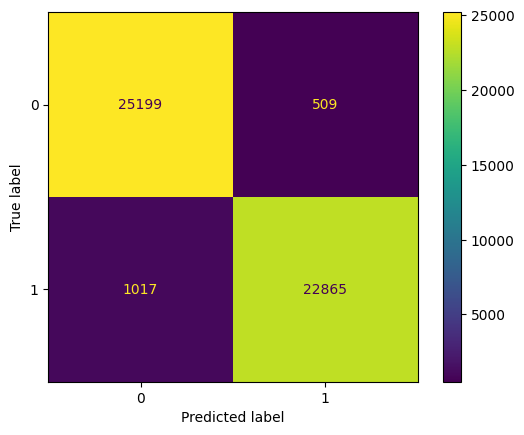

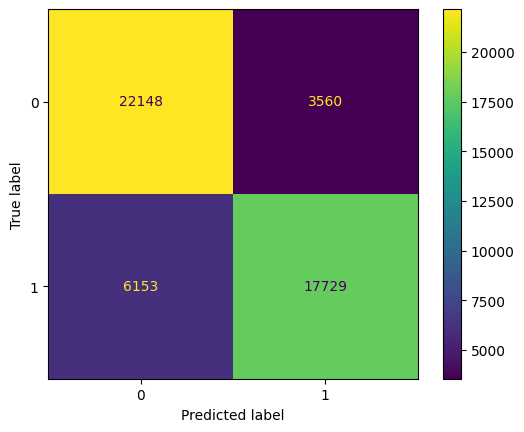

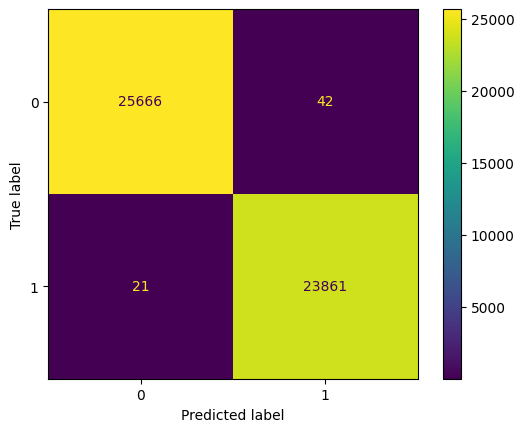

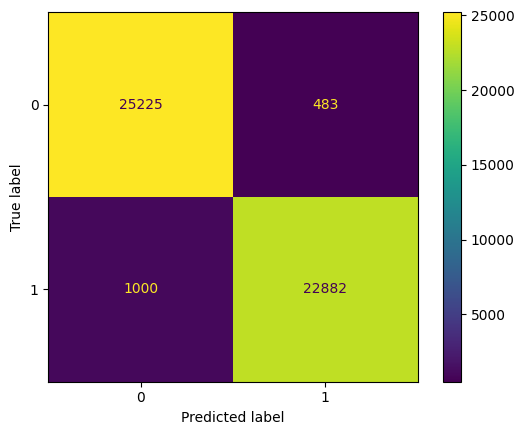

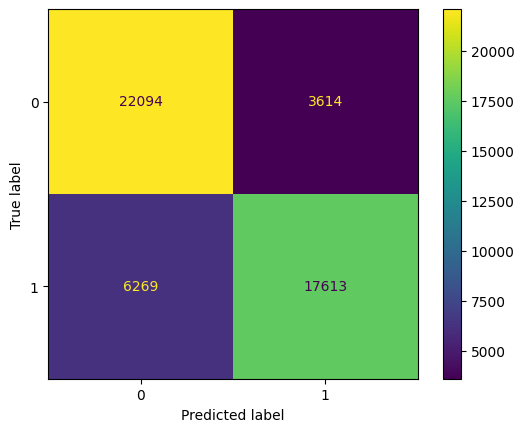

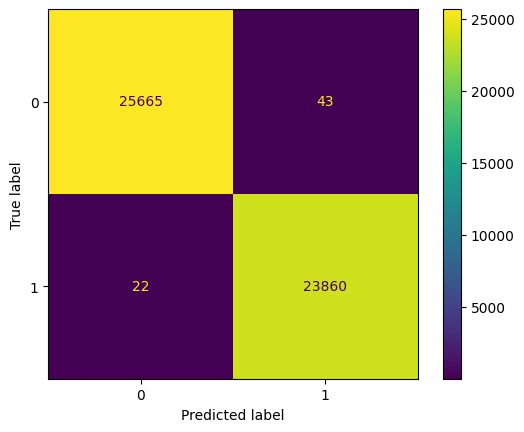

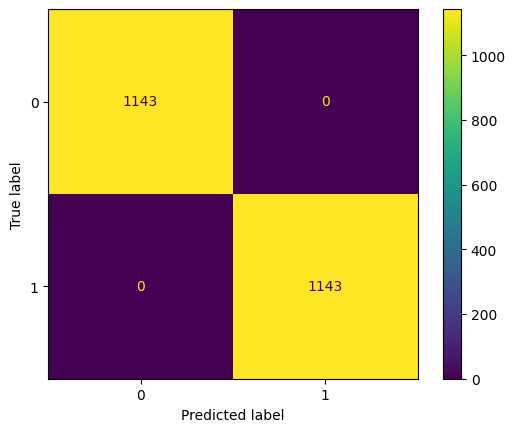

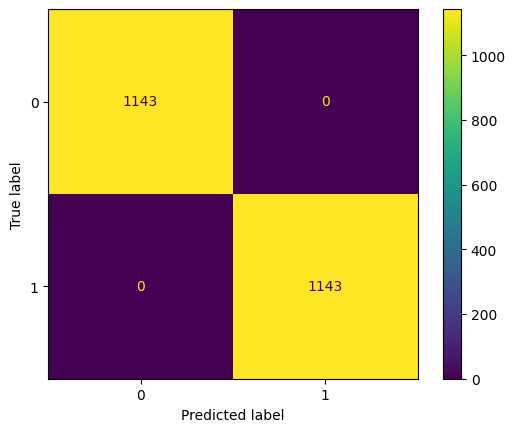

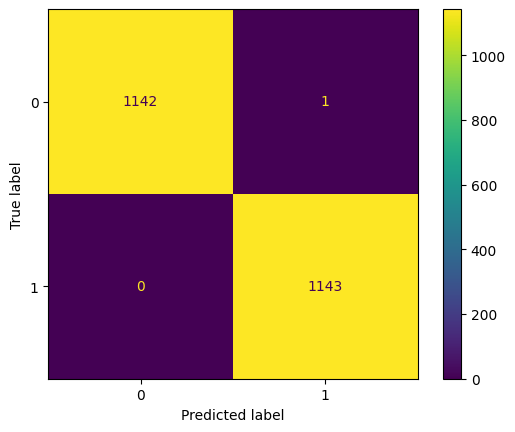

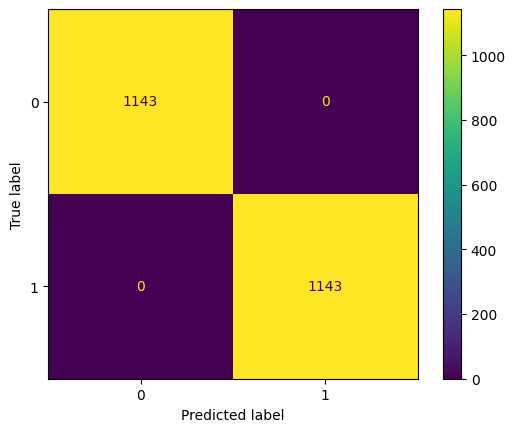

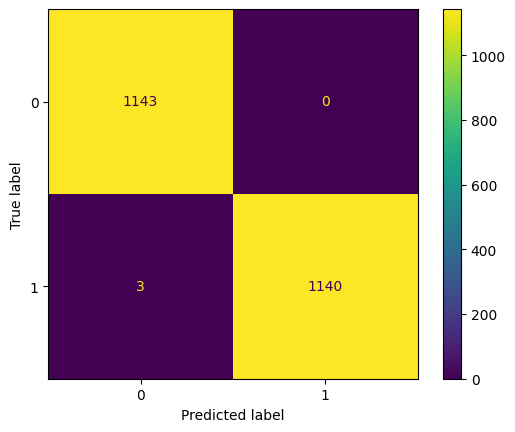

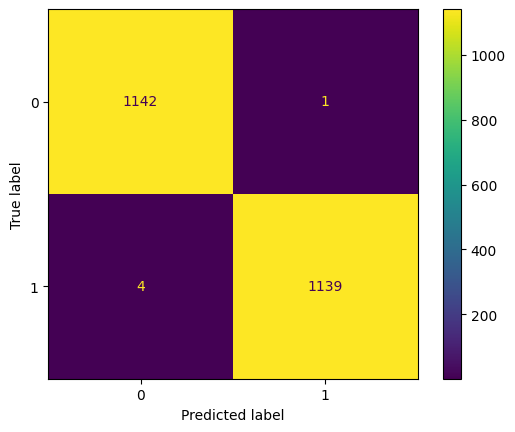

In [10]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, f1_score, precision_score, recall_score

def train_feature_selection(dataset, model, feature_list, ds_name, model_name, baseline_method):
    model_clone = clone(model)

    # combine train + val
    X_full = pd.concat([dataset["x_train"], dataset["x_val"]])
    y_full = pd.concat([dataset["y_train"], dataset["y_val"]])

    X_test = dataset["x_test"]
    y_test = dataset["y_test"]

    X_full_selected = X_full[list(feature_list)]
    X_test_selected = X_test[list(feature_list)]

    model_clone.fit(X_full_selected, y_full)
    y_pred = model_clone.predict(X_test_selected)
    print(f"\nTest Set Performance - {model_name} {ds_name} {baseline_method}")
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    print(classification_report(y_test, y_pred))

    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    #save trained model
    joblib.dump(model_clone, f"./models/phase_2/{model_name.lower()}_{ds_name.lower()}_fs_{baseline_method.lower()}.joblib")

    return {
        "Dataset": ds_name,
        "Model": model_name,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "Num_Features": len(feature_list),
        "Method": baseline_method
    }

os.makedirs("./models/phase_2", exist_ok=True)

#train models and save results
final_results = []
final_results.append(train_feature_selection(mendeley_sets, xgb_mendeley, mendeley_union, "Mendeley", "XGBoost", "Union"))
final_results.append(train_feature_selection(mendeley_sets, logreg_mendeley, mendeley_union, "Mendeley", "LogReg", "Union"))
final_results.append(train_feature_selection(mendeley_sets, rf_mendeley, mendeley_union, "Mendeley", "RF", "Union"))

final_results.append(train_feature_selection(mendeley_sets, xgb_mendeley, mendeley_intersection, "Mendeley", "XGBoost", "Intersection"))
final_results.append(train_feature_selection(mendeley_sets, logreg_mendeley, mendeley_intersection, "Mendeley", "LogReg", "Intersection"))
final_results.append(train_feature_selection(mendeley_sets, rf_mendeley, mendeley_intersection, "Mendeley", "RF", "Intersection"))

final_results.append(train_feature_selection(kaggle_sets, xgb_kaggle, kaggle_union, "Kaggle", "XGBoost", "Union"))
final_results.append(train_feature_selection(kaggle_sets, logreg_kaggle, kaggle_union, "Kaggle", "LogReg", "Union"))
final_results.append(train_feature_selection(kaggle_sets, rf_kaggle, kaggle_union, "Kaggle", "RF", "Union"))

final_results.append(train_feature_selection(kaggle_sets, xgb_kaggle, kaggle_intersection, "Kaggle", "XGBoost", "Intersection"))
final_results.append(train_feature_selection(kaggle_sets, logreg_kaggle, kaggle_intersection, "Kaggle", "LogReg", "Intersection"))
final_results.append(train_feature_selection(kaggle_sets, rf_kaggle, kaggle_intersection, "Kaggle", "RF", "Intersection"))


In [11]:
def plot_f1_vs_k(file_path, method_name):
    df = pd.read_csv(file_path)

    for dataset in df["Dataset"].unique():
        subset = df[df["Dataset"] == dataset]

        plt.figure()

        for model in subset["Model"].unique():
            model_df = subset[subset["Model"] == model]
            plt.plot(model_df["k"], model_df["f1_Score"], marker='o', label=model)

        plt.title(f"{method_name} F1 vs K - {dataset}")
        plt.xlabel("K (Number of Features)")
        plt.ylabel("F1 Score")
        plt.legend()
        plt.grid()

        plt.savefig(f"../results/phase_2/plots/{method_name}_f1_vs_k_{dataset}.png")
        plt.close()
        
plot_f1_vs_k("../results/phase_2/data/mi_feature_selection_results.csv", "MI")
plot_f1_vs_k("../results/phase_2/data/chi2_feature_selection_results.csv", "Chi2")
plot_f1_vs_k("../results/phase_2/data/anova_feature_selection_results.csv", "ANOVA")

df_files = [f for f in os.listdir("../results/phase_2/data") if "final_summary" in f]

dfs = [pd.read_csv(f"../results/phase_2/data/{f}") for f in df_files]
summary_df = pd.concat(dfs, ignore_index=True)

for dataset in summary_df["Dataset"].unique():
    subset = summary_df[summary_df["Dataset"] == dataset]

    plt.figure()

    for model in subset["Model"].unique():
        model_df = subset[subset["Model"] == model]
        plt.bar(model_df["Method"] + "_" + model, model_df["Test_F1"])

    plt.xticks(rotation=45)
    plt.title(f"Feature Selection Method Comparison - {dataset}")
    plt.ylabel("Test F1 Score")

    plt.savefig(f"../results/phase_2/plots/method_comparison_{dataset}.png")
    plt.close()
    
df = pd.DataFrame(final_results)

for dataset in df["Dataset"].unique():
    subset = df[df["Dataset"] == dataset]

    plt.figure()

    for model in subset["Model"].unique():
        model_df = subset[subset["Model"] == model]
        plt.bar(model_df["Method"] + "_" + model, model_df["F1"])

    plt.xticks(rotation=45)
    plt.title(f"Union vs Intersection - {dataset}")
    plt.ylabel("F1 Score")

    plt.savefig(f"../results/phase_2/plots/union_vs_intersection_{dataset}.png")
    plt.close()
    
# Mendeley
plt.figure()
plt.bar(["Union", "Intersection"], [len(mendeley_union), len(mendeley_intersection)])
plt.title("Feature Count - Mendeley")
plt.ylabel("Number of Features")
plt.savefig("../results/phase_2/plots/mendeley_feature_count.png")
plt.close()

# Kaggle
plt.figure()
plt.bar(["Union", "Intersection"], [len(kaggle_union), len(kaggle_intersection)])
plt.title("Feature Count - Kaggle")
plt.ylabel("Number of Features")
plt.savefig("../results/phase_2/plots/kaggle_feature_count.png")
plt.close()

from collections import Counter
import ast

all_features = []

for feature_list in summary_df["Features_Used"]:
    try:
        features = ast.literal_eval(feature_list)
        all_features.extend(features)
    except:
        continue

feature_counts = Counter(all_features)

plt.figure()
plt.hist(list(feature_counts.values()), bins=20)
plt.title("Feature Stability Distribution")
plt.xlabel("Selection Frequency")
plt.ylabel("Number of Features")

plt.savefig("../results/phase_2/plots/feature_stability.png")
plt.close()